In [105]:
import jax.numpy as jnp
from jax import grad, jit, vmap, jacfwd, jacrev, random
from jax import random, device_put
#rom jax.scipy.special import kl_div

# from jax import config
# config.update("jax_enable_x64", True)

import numpy as np
from scipy.interpolate import interp1d
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.size'] = 12

import seaborn as sns
# Scientific plot styles
sns.set_context('paper')
sns.set_style('dark')
sns.set_style("ticks")
sns.set_palette('colorblind')
sns.set_style({'font.sans-serif':'cmr10', 'text.usetex':True, 'font.size':12})


import copy
import time
rng = np.random.default_rng()
key = random.PRNGKey(0)

from pathgradient import *
import sampling

PARAMS_LATEX = {'disp_parameter': r'$\lambda$',
                'alpha': r'$\alpha$',
                'beta': r'$\beta$'}

In [2]:
# Get the gradients of the CDF with respect to the parameters

# Final energy (x)
grad_x_cdf = jit(jacfwd(jax_cdf_differential_decay_width, argnums=0))
# Initial energy (Ei)
grad_Ei_cdf = jit(jacfwd(jax_cdf_differential_decay_width, argnums=1))
# Parameters (theta)
grad_theta_cdf = jit(jacfwd(jax_cdf_differential_decay_width, argnums=3))

# -----------------------------------------------
# Get the gradients of the final energy

# Gradient of the final energy with respect to the parameters
def grad_theta_x(final_energy, initial_energy, meta_params, params):
    grad_theta_x_val = {}
    grad_x_cdf_val = grad_x_cdf(final_energy, initial_energy, meta_params, params)
    grad_theta_cdf_val = grad_theta_cdf(final_energy, initial_energy, meta_params, params)

    for param in params:
        grad_theta_x_val[param] = - grad_theta_cdf_val[param] / grad_x_cdf_val

    return grad_theta_x_val

# Gradient of the final energy with respect to the initial energy
def grad_Ei_x(final_energy, initial_energy, meta_params, params):
    grad_Ei_x_val = {}
    grad_x_cdf_val = grad_x_cdf(final_energy, initial_energy, meta_params, params)
    grad_Ei_cdf_val = grad_Ei_cdf(final_energy, initial_energy, meta_params, params)

    for param in params:
        grad_Ei_x_val[param] = - grad_Ei_cdf_val[param] / grad_x_cdf_val

    return grad_Ei_x_val


In [ ]:
# Timing and shapes

initial_energy = 23.0
final_energy = 15.0

discrete_energies = DISCRETE_ENERGIES
discrete_continuum_boundary = DISCRETE_CONTINUUM_BOUNDARY
meta_params = META_PARAMS

disp_parameter = 0.01
alpha = 1.0
beta = 10.0
params = {'disp_parameter': disp_parameter,
            'alpha': alpha,
            'beta': beta}

# %timeit grad_x_cdf_val = grad_x_cdf(final_energy, initial_energy, meta_params, params)
# %timeit grad_Ei_cdf_val = grad_Ei_cdf(final_energy, initial_energy, meta_params, params)
# %timeit grad_theta_cdf_val = grad_theta_cdf(final_energy, initial_energy, meta_params, params)
%timeit grad_theta_x_val = grad_theta_x(final_energy, initial_energy, meta_params, params)
%timeit grad_theta_x_jit_val = grad_theta_x_jit(final_energy, initial_energy, meta_params, params)

# grad_x_cdf_val = grad_x_cdf(final_energy, initial_energy, meta_params, params)
# print(grad_x_cdf_val.shape, type(grad_x_cdf_val))
# grad_Ei_cdf_val = grad_Ei_cdf(final_energy, initial_energy, meta_params, params)
# print(grad_Ei_cdf_val.shape, type(grad_Ei_cdf_val))
# grad_theta_cdf_val = grad_theta_cdf(final_energy, initial_energy, meta_params, params)
# print(type(grad_theta_cdf_val))
# print(grad_theta_cdf_val["disp_parameter"])

In [ ]:
# Finite differences test

initial_energy = 23.0
final_energy = 15.0

meta_params = META_PARAMS

disp_parameter = 0.01
alpha = 1.0
beta = 10.0
params = {'disp_parameter': disp_parameter,
            'alpha': alpha,
            'beta': beta}

epsilon = 1e-5
# Sample an event
r = 0.4
next_energy, continuum_cut = spicy_inverse_cdf_differential_decay_width(
                                                    r, initial_energy, meta_params, params)

# Sample other close events
params_plus = {'disp_parameter': disp_parameter + epsilon, 'alpha': alpha, 'beta': beta}
next_energy_plus, continuum_cut_plus = spicy_inverse_cdf_differential_decay_width(
                                                    r, initial_energy, meta_params, params_plus)

params_minus = {'disp_parameter': disp_parameter - epsilon, 'alpha': alpha, 'beta': beta}
next_energy_minus, continuum_cut_minus = spicy_inverse_cdf_differential_decay_width(
                                                    r, initial_energy, meta_params, params_minus)


# Calculate the gradient with finite differences and with the analytical jax gradient
print(next_energy, "NE", continuum_cut, "CC")
grad_theta_x_fd = (next_energy_plus - next_energy_minus) / (2 * epsilon)
grad_theta_x_jx = grad_theta_x(next_energy, initial_energy, meta_params, params)

print(grad_theta_x_fd, grad_theta_x_jx, "chirp")


In [ ]:
%matplotlib widget

sample_num = 5000
num_passes = 5
initial_energy = 23.0 * np.ones(sample_num)
meta_params = META_PARAMS
params = {'disp_parameter': 0.01,
            'alpha': 1.0,
            'beta': 10.0}

key = random.PRNGKey(0)

energies, continuum_cuts = sampling.sample_continuum_path(initial_energy, meta_params, params, 
                                        key, sample_num=sample_num, passes=num_passes,
                                        max_continuum_steps=2, use_continuum_cut=True)


print(np.where(energies[0] == 23.0))

# Plot
plt.figure()
plt.scatter(energies[0], energies[1], s=4)
# Plot the x=y line
discrete_continuum_boundary = meta_params['discrete_continuum_boundary']
plt.plot([-1, 23], [-1, 23], color='black', linestyle='--')
# Set the axis limits
# plt.xlim([discrete_continuum_boundary, 23])
# plt.ylim([discrete_continuum_boundary, 23])
# Set aspect ratio to 1
plt.gca().set_aspect('equal', adjustable='box')

plt.figure()
# 2D hist with a log cmap
bins_x = np.linspace(discrete_continuum_boundary, 23, 100)
bins_y = np.linspace(discrete_continuum_boundary, 23, 100)
plt.hist2d(energies[0], energies[1], bins=[bins_x, bins_y], cmap='gnuplot', norm = mpl.colors.LogNorm())
# Set aspect ratio to 1
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar()

plt.figure()


## Test the discrete probability computation and sampling

In [2]:
#initial_energy = 23.0 * np.ones(sample_num)
meta_params = META_PARAMS
params = {'disp_parameter': 0.01,
            'alpha': 1.0,
            'beta': 10.0}


continuum_energy = 17.02

discrete_path_probs_body, discrete_paths = sampling.get_discrete_tree_body(meta_params, params)

discrete_path_probs, discrete_paths = sampling.get_full_discrete_tree(continuum_energy, (discrete_path_probs_body, discrete_paths), meta_params, params)

print(discrete_paths.shape, discrete_path_probs.shape)

# Should add up to 1
print(np.sum(discrete_path_probs))

# Should add up to 1
starting_discrete_level = 6
total_prob = 0.0
for i, path in enumerate(discrete_paths):
    if path[0] == starting_discrete_level:
        total_prob += discrete_path_probs_body[i]
print(total_prob)   

(128, 8) (128,)
1.0
1.0000000237487257


In [3]:
# Sampling 
meta_params = META_PARAMS
params = {'disp_parameter': 0.01,
            'alpha': 1.0,
            'beta': 10.0}

continuum_energy = 13.4

key, subkey = random.split(key)
start = time.time()
for i in range(1000):
    key, subkey = random.split(key)
    discrete_path = sampling.sample_discrete_path_obo(continuum_energy, meta_params, params, subkey)

end = time.time()
print(end - start)

print(np.array(discrete_path))


3.360678195953369
[5 1 0]


In [4]:
# Sampling using discrete tree
meta_params = META_PARAMS
params = {'disp_parameter': 0.01,
            'alpha': 1.0,
            'beta': 10.0}

# Tree body
discrete_path_probs_body, discrete_paths = sampling.get_discrete_tree_body(meta_params, params)

key, subkey = random.split(key)
continuum_energies = random.uniform(subkey, shape=(1000,), minval=meta_params['discrete_continuum_boundary'], maxval=23.0)
discrete_path_probs, discrete_paths = sampling.get_full_discrete_tree_vmap(continuum_energies, (discrete_path_probs_body, discrete_paths), meta_params, params)

print(discrete_paths.shape, discrete_path_probs.shape)

# Now we sample
key, subkey = random.split(key)
# random_numbers = random.uniform(subkey, shape=(10000,))

# discrete_path_probs_cumsum = jnp.cumsum(discrete_path_probs, axis=1)
# path_indices = np.array([np.searchsorted(row, rnd_num) for row, rnd_num in zip(discrete_path_probs_cumsum, random_numbers)])
# print(discrete_paths[path_indices])

path_indices, paths, path_energies = sampling.sample_discrete_path(continuum_energies, 
                                                        (discrete_path_probs, discrete_paths), meta_params, params, subkey)

print(path_indices.shape, paths.shape, path_energies.shape)


(128, 8) (1000, 128)
(1000,) (1000, 8) (1000, 8)


In [3]:
# Function to sample a full set of paths
def sample_full_path(initial_energy, meta_params, params, key, cdf_root_fun, sample_num):
    num_passes = 1
    max_continuum_steps = 4

    # First, sample the continuum paths
    key, subkey = random.split(key)
    continuum_energies, last_continuum_energies, last_continuum_energies_idx, continuum_cuts,\
            energy_theta_gradients,energy_total_theta_gradients, energy_Ei_gradients, continuum_cut_gradients =\
                sampling.sample_continuum_path(initial_energy, meta_params, params, 
                                            subkey, cdf_root_fun, sample_num=sample_num, passes=num_passes,
                                            max_continuum_steps=max_continuum_steps, use_continuum_cut=True)

    print("Continuum energies shape:", continuum_energies.shape, continuum_cuts.shape)
    # Now, see when the continuum paths go to discrete
    # This is the last entry of the continuum path before it hits -1

    # Get the indices of the last entry before the continuum path hits -1
    first_minus_one_index = np.argmax((continuum_energies == -1.), axis=1)
    keep_paths = np.where(first_minus_one_index != 0)[0]

    print(continuum_energies[0, :])
    print(first_minus_one_index[0], first_minus_one_index.shape)

    # Get rid of continuum paths that never hit -1, and the last continuum energies
    #last_continuum_energies = np.array([continuum_energies[i, first_minus_one_index[i]-1] for i in keep_paths])
    filtered_continuum_energies = continuum_energies[keep_paths, :]
    last_continuum_energies = last_continuum_energies[keep_paths]

    print(filtered_continuum_energies.shape, last_continuum_energies.shape)

    # Now, sample the discrete paths
    # Get the discrete tree
    key, subkey = random.split(key)
    discrete_path_probs_body, discrete_paths = sampling.get_discrete_tree_body(meta_params, params)
    discrete_path_probs, discrete_paths = sampling.get_full_discrete_tree_vmap(last_continuum_energies, (discrete_path_probs_body, discrete_paths), meta_params, params)

    # Sample the discrete paths (leaving JAX)
    discrete_path_indices, discrete_paths, discrete_path_energies = sampling.sample_discrete_path(last_continuum_energies, 
                                                            (discrete_path_probs, discrete_paths), meta_params, params, subkey)

    print(discrete_path_indices.shape, discrete_paths.shape, discrete_path_energies.shape)

    # Finally, combine the continuum and discrete paths and get rid of any trailing -1s and 0s
    # Combine the energy paths
    full_energy_paths = sampling.stitch_paths(filtered_continuum_energies, discrete_path_energies)

    return continuum_energies, last_continuum_energies, last_continuum_energies_idx, continuum_cuts,\
            energy_theta_gradients, energy_total_theta_gradients, energy_Ei_gradients, continuum_cut_gradients,\
                discrete_path_indices, discrete_paths, discrete_path_energies,\
                    filtered_continuum_energies, full_energy_paths


# idx = 0
# print(filtered_continuum_energies[idx], discrete_path_energies[idx])
# print(combined_energies[idx])

In [4]:
# Really, now let's sample a full set of paths

sample_num = 5000
num_passes = 1
max_continuum_steps = 4
initial_energy = 23.0 * np.ones(sample_num)

meta_params = META_PARAMS
params = {'disp_parameter': 1.5,
            'alpha': 1.0,
            'beta': 1.0}

key, subkey = random.split(key)

continuum_energies, last_continuum_energies, last_continuum_energies_idx, continuum_cuts,\
    energy_theta_gradients, energy_total_theta_gradients, energy_Ei_gradients, continuum_cut_gradients,\
    discrete_path_indices, discrete_paths, discrete_path_energies,\
    filtered_continuum_energies, full_energy_paths =\
        sample_full_path(initial_energy, meta_params, params, subkey, jax_cdf_minimum, sample_num)

Pass 1 of 1
Continuum energies shape: (5000, 6) (5000, 6)
[23. -1. -1. -1. -1. -1.]
1 (5000,)
(4995, 6) (4995,)
(4995,) (4995, 8) (4995, 8)


In [18]:
%load_ext line_profiler

sample_num = 2000
num_passes = 1
max_continuum_steps = 4
initial_energy = 23.0 * np.ones(sample_num) + np.random.normal(size=(sample_num,)) * 2

meta_params = META_PARAMS
params = {'disp_parameter': 0.010,
            'alpha': 1.0,
            'beta': 10.0}

key, subkey = random.split(key)
discrete_continuum_boundary = meta_params['discrete_continuum_boundary']
upper = np.max(initial_energy)

%lprun -f sample_full_path sample_full_path(initial_energy, meta_params, params, key, jax_cdf_minimum, sample_num)
# %lprun -f sampling.sample_continuum_path sampling.sample_continuum_path(initial_energy, meta_params, params,\
#                                             subkey, jax_cdf_minimum, sample_num=sample_num, passes=num_passes,\
#                                             max_continuum_steps=max_continuum_steps, use_continuum_cut=True)

#spicy_inverse_cdf_differential_decay_width(np.array([0.3,0.4]), np.array([23.0, 23.0]), meta_params, params, jax_cdf_minimum)
#solver = jaxopt.Bisection(optimality_fun=jax_cdf_minimum, lower=discrete_continuum_boundary, upper=upper, jit=True, check_bracket=False)

#rand = rng.uniform(size=(sample_num,))
#%lprun -f spicy_inverse_cdf_differential_decay_width spicy_inverse_cdf_differential_decay_width(rand, initial_energy, meta_params, params, jax_cdf_minimum)

#%lprun -f spicy_inverse_cdf_differential_decay_width_jit spicy_inverse_cdf_differential_decay_width_jit(rand, initial_energy, meta_params, params, jax_cdf_minimum)


Pass 1 of 1
*** KeyboardInterrupt exception caught in code being profiled.

Timer unit: 1e-09 s

Total time: 1.41693 s
File: /var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_37015/2403095307.py
Function: sample_full_path at line 2

Line #      Hits         Time  Per Hit   % Time  Line Contents
     2                                           def sample_full_path(initial_energy, meta_params, params, key, cdf_root_fun, sample_num):
     3         1       1000.0   1000.0      0.0      num_passes = 1
     4         1          0.0      0.0      0.0      max_continuum_steps = 4
     5                                           
     6                                               # First, sample the continuum paths
     7         1     400000.0 400000.0      0.0      key, subkey = random.split(key)
     8                                               continuum_energies, last_continuum_energies, last_continuum_energies_idx, continuum_cuts,\
     9                                                       energy_theta_gradients,energy_total_theta_gradients, energ

[23.         12.79644012 -1.         -1.         -1.         -1.        ] [8. 0. 0. 0. 0. 0. 0. 0.]
[23.         12.79644012  5.          3.          0.        ]
------


/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/2878089030.py:19: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.axhspan(discrete_continuum_boundary * 1.01, initial_energy * 1.1, alpha=0.3, color='blue')
/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/2878089030.py:38: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.axhspan(discrete_continuum_boundary * 1.01, initial_energy * 1.1, alpha=0.3, color='blue')


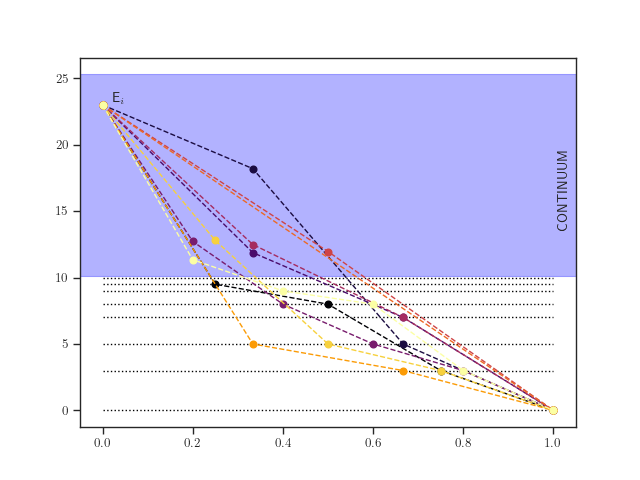

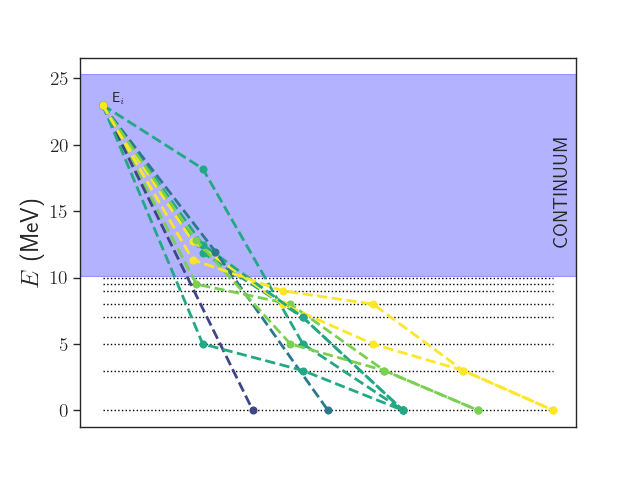

In [128]:
# Plot some shit 

initial_energy = 23.0
discrete_continuum_boundary = meta_params['discrete_continuum_boundary']
discrete_energies = meta_params['discrete_energies']

num_paths = 10
full_level_paths = full_energy_paths[0:num_paths]
#print(combined_energies[1])

idx = 8
print(filtered_continuum_energies[idx], discrete_path_energies[idx])
print(full_energy_paths[idx])
print('------')

%matplotlib widget
plt.figure()
# Plot the continuum energy range (from discrete/continuum boundary to start energy) as a rectangle
plt.axhspan(discrete_continuum_boundary * 1.01, initial_energy * 1.1, alpha=0.3, color='blue')
# Add a "CONTINUUM" label to the right, rotated 90 degrees
plt.text(1.01, (discrete_continuum_boundary + initial_energy)/2, 'CONTINUUM', rotation=90, verticalalignment='center', horizontalalignment='left')
# Plot the discrete energy levels as horizontal lines
plt.hlines(discrete_energies, 0, 1, color='black', linewidth=1, linestyles='dotted')

# Add a label for the initial energy
plt.text(0.05, initial_energy, r'E$_i$', verticalalignment='bottom', horizontalalignment='right')
cmap = plt.cm.inferno
colors = cmap(np.linspace(0, 1, num_paths))

for i, full_level_path in enumerate(full_level_paths):
    #print(full_level_path)

    # Plot the full energy path as a scatter joined with dashed lines
    plt.plot(np.linspace(0, 1, len(full_level_path)), full_level_path, color=colors[i], linestyle='--', marker='o', linewidth=1)

# -------------------------------------------------------------------
plt.figure()
plt.axhspan(discrete_continuum_boundary * 1.01, initial_energy * 1.1, alpha=0.3, color='blue')
plt.text(1.00, (discrete_continuum_boundary + initial_energy)/2, 'CONTINUUM', rotation=90, verticalalignment='center', horizontalalignment='left', size=14)
plt.hlines(discrete_energies, 0, 1, color='black', linewidth=1, linestyles='dotted')
plt.text(0.05, initial_energy, r'E$_i$', verticalalignment='bottom', horizontalalignment='right')

# Get rid of the x ticks
plt.xticks([])
plt.ylabel(r'$E$ (MeV)', size=18)
plt.tick_params(axis='both', which='major', labelsize=14)
# Maximum path length
max_path_length = np.max([len(path) for path in full_level_paths])

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, max_path_length))

for i, full_level_path in enumerate(full_level_paths):
    # Plot the full energy path as a scatter joined with dashed lines

    # Color according to the path length
    color = colors[len(full_level_path)-1]

    plt.plot(np.linspace(0, len(full_level_path)/max_path_length, len(full_level_path)), full_level_path, color=color, linestyle='--', marker='o', linewidth=2.0, alpha=1.0)



/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/731534298.py:14: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()
/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/731534298.py:104: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(scatter)


[23.         14.71918488 13.05779266 10.90395737] [ 0.         16.69960594 -1.91192794 -0.19280672]
[23.         13.17501831 11.34968281 10.52589989 10.        ] [ 0.         29.87239647 36.59356308 -3.33729482 -1.98151684]
HOP
[23.         18.34558105 16.51616669 11.26145363] [ 0.         22.30386925  2.99717736 -9.627635  ]
[True, True, True, True]


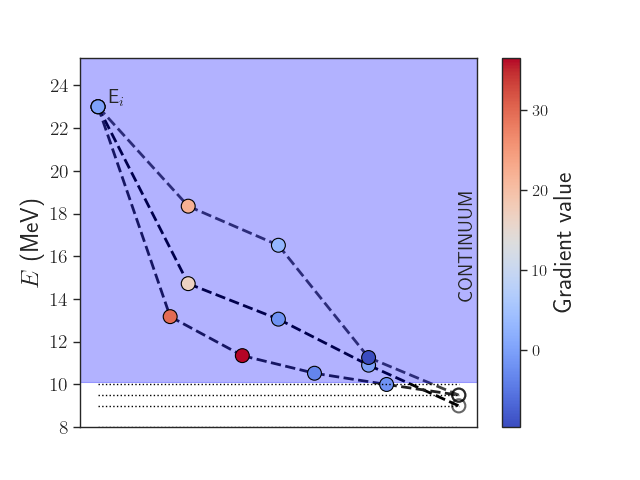

In [183]:
# Plot some continuum paths with each point colored by their gradient
%matplotlib widget
initial_energy = 23.0
discrete_continuum_boundary = meta_params['discrete_continuum_boundary']
discrete_energies = meta_params['discrete_energies']

num_paths = 5000
num_to_plot = 4
max_path_length = 6

full_level_paths = full_energy_paths[0:num_paths]
energy_total_theta_gradients_val = {p:energy_total_theta_gradients[p][0:num_paths] for p in params}

fig, ax = plt.subplots()
# Plot the continuum energy range (from discrete/continuum boundary to start energy) as a rectangle
plt.axhspan(discrete_continuum_boundary * 1.01, initial_energy * 1.1, alpha=0.3, color='blue')
# Add a "CONTINUUM" label to the right, rotated 90 degrees
ax.text(1.00, (discrete_continuum_boundary + initial_energy)/2, 'CONTINUUM', rotation=90, verticalalignment='center', horizontalalignment='left', size=14)
# Plot the discrete energy levels as horizontal lines
ax.hlines(discrete_energies, 0, 1, color='black', linewidth=1, linestyles='dotted')
ax.set_xticks([])
ax.set_ylim([discrete_continuum_boundary * 0.8, initial_energy * 1.1])

ax.set_ylabel(r'$E$ (MeV)', size=18)
ax.tick_params(axis='both', which='major', labelsize=14)

# Add a label for the initial energy
plt.text(0.075, initial_energy, r'E$_i$', verticalalignment='bottom', horizontalalignment='right', size=14)

# We will look for a few paths with different characteristics
checklist = [False, False, False, False]
to_scatter_x = []
to_scatter_y = []
to_scatter_colors = []
plotted = 0

path_cmap = plt.cm.grey
path_colors = path_cmap(np.linspace(0, 1, num_to_plot+5))

for i, full_level_path in enumerate(full_level_paths):
    if plotted == num_to_plot:
        break
    
    cont_lim = np.argmax(full_level_path < discrete_continuum_boundary)

    if cont_lim < 3:
        continue

    if np.any(full_level_path[:cont_lim] < 10):
        continue
    
    # if np.any(np.abs(energy_total_theta_gradients_val['alpha'][i, :cont_lim]) > 20):
    #     continue

    checks = [False, False, False, False]
    # Checklist
    if not checklist[0] and cont_lim >= 5:
        checks[0] = True
        checklist[0] = True
    elif not checklist[1] and cont_lim >= 4:
        checks[1] = False
        checklist[1] = True
    elif not checklist[2] and cont_lim >=4 and full_level_path[1] >= 18 and full_level_path[2] >=16:
        print("HOP")
        checks[2] = True
        checklist[2] = True
    elif not checklist[3] and cont_lim >=4 and full_level_path[1] >= 14 and full_level_path[2] >=13:
        checks[3] = True
        checklist[3] = True
    # elif cont_lim >=4 and cont_lim >=4 and full_level_path[1] >= 16:
    #     checks[4] = True
    #     checklist[4] = True

    if not np.any(checks):
        continue

    plotted += 1

    # Plot the continuum part of the energy path as a scatter colored by the gradient
    x_axis = np.linspace(0, (cont_lim+1)/max_path_length, cont_lim + 1)
    x_axis = np.linspace(0, 1, cont_lim + 1)
    to_scatter_x.extend(list(x_axis[:-1]))
    to_scatter_y.extend(list(full_level_path[:cont_lim]))
    to_scatter_colors.extend(list(np.nan_to_num(energy_total_theta_gradients_val['alpha'][i, :cont_lim])))

    print(full_level_path[:cont_lim], energy_total_theta_gradients_val['alpha'][i, :cont_lim])

    
    # Plot the discrete energies
    ax.scatter(x_axis[-1], full_level_path[cont_lim], alpha=0.6, s=90, marker='o', facecolors='none', edgecolors='black', zorder=100, linewidths=1.5)

    # Plot lines between the (future) points
    path_color = path_colors[plotted-1]
    for j in range(cont_lim):
        ax.plot([x_axis[j], x_axis[j+1]], [full_level_path[j], full_level_path[j+1]], color=path_color, linestyle='--', zorder=-1, linewidth=2.0)


# The scatter is done all at once outside of the loop so we can add a consistent colorbar

scatter = ax.scatter(to_scatter_x, to_scatter_y, c=to_scatter_colors, 
            cmap='coolwarm', marker='o', s=100, edgecolors='black')

# Add a colorbar
cbar = fig.colorbar(scatter)
cbar.set_label('Gradient value', size=18)
cbar.ax.tick_params(labelsize=12)

print(checklist)

# Save the figure as svg
plt.savefig('saved_images/{}'.format('gradient_paths.svg'), format='svg', dpi=1200)
    

## Minimization

In [7]:
def gaussian_kernel(x, y, sigma=1.0):
    return jnp.exp(-jnp.sum((x - y)**2) / (2 * sigma**2))

def mmd_loss(x, y, kernel):
    # y is SIMULATED, x is TRUTH (doesn't matter, it's symmetric)
    x_kernel = jnp.mean(vmap(lambda xi: jnp.mean(vmap(lambda xj: kernel(xi, xj))(x)))(x))
    y_kernel = jnp.mean(vmap(lambda yi: jnp.mean(vmap(lambda yj: kernel(yi, yj))(y)))(y))
    xy_kernel = jnp.mean(vmap(lambda xi: jnp.mean(vmap(lambda yj: kernel(xi, yj))(y)))(x))
    return jnp.mean(x_kernel + y_kernel - 2 * xy_kernel)

def gaussian_kernel_obo(x, y, sigma=1.0):

    bandwidth_range = np.array([0.1, 1.0, 2.0, 10., 15., 20., 50., 100., 150.])
    #bandwidth_range = np.array([15., 50., 150., 250.])
    kernel = 0.0

    for bw in bandwidth_range:
        kernel += jnp.exp(-(x - y)**2 / (2 * bw))

    return kernel

gaussian_kernel_vmap_1 = vmap(gaussian_kernel_obo, in_axes=(0, None), out_axes=0)
gaussian_kernel_vmap = vmap(gaussian_kernel_vmap_1, in_axes=(None, 0), out_axes=1)

def mmd_loss_x_kernel(x, kernel_vmap):
    m = x.shape[0]
    kernel_x_matrix = kernel_vmap(x, x)

    x_kernel = 1 / (m * (m - 0)) * jnp.sum(kernel_x_matrix)
    return x_kernel

def mmd_loss_weighted(x, y, weights, kernel_vmap):
    # y is SIMULATED, x is TRUTH (doesn't matter, it's symmetric)
    m = x.shape[0]
    n = y.shape[0]
    n_weighted = jnp.sum(weights)

    #kernel_x_matrix = kernel_vmap(x, x)
    kernel_y_matrix = kernel_vmap(y, y)
    kernel_xy_matrix = kernel_vmap(x, y)
    # Make the diagonal entries 0
    #kernel_x_matrix = jnp.where(jnp.eye(m), 0, kernel_x_matrix)
    #kernel_y_matrix = jnp.where(jnp.eye(n), 0, kernel_y_matrix)
    # print(kernel_x_matrix[5,5], "kxm")

    weights_2d = jnp.outer(weights, weights)
    diag_weights = jnp.einsum('ii', weights_2d) * 0
    sum_weights = jnp.sum(weights_2d)

    x_kernel = 0 # 1 / (m * (m - 0)) * jnp.sum(kernel_x_matrix)
    y_kernel = 1 / (sum_weights - diag_weights) * jnp.sum(kernel_y_matrix * weights_2d)
    xy_kernel = 1 / (m * n_weighted) * jnp.sum(kernel_xy_matrix * jnp.repeat(weights[jnp.newaxis, :], m, axis=0))

    # print(jnp.repeat(weights[jnp.newaxis, :], m, axis=0).shape)
    # print(x_kernel, y_kernel, 2*xy_kernel)

    return x_kernel + y_kernel - 2 * xy_kernel

mmd_loss_weighted = jit(mmd_loss_weighted, static_argnums=(3,))

# -----------------------------------------------

key, *subkeys = random.split(key, 4)
x = random.normal(subkeys[0], shape=(100,))
y = random.normal(subkeys[1], shape=(900,)) * 1.2

#weights = jnp.ones(y.shape[0]) * 0.6
#weights = random.uniform(subkeys[2], shape=(y.shape[0],))
#print(mmd_loss(x, y, gaussian_kernel))

#mmdw = mmd_loss_weighted(x, y, weights, gaussian_kernel_vmap)
#print(mmdw)
# print(mmd_loss_weighted(y, x, weights, gaussian_kernel_vmap))

# Gradients
grad_mmd_loss = grad(mmd_loss, argnums=1)
#print(grad_mmd_loss(x, y, gaussian_kernel)[0])

grad_mmd_loss_weighted = jit(grad(mmd_loss_weighted, argnums=1), static_argnums=(3,))
#print(grad_mmd_loss_weighted(x, y, weights, gaussian_kernel_vmap)[0])

In [32]:
# Loss of sum vs sum of losses

y1 = jnp.array([1.1, 2.2, 3.3])
y2 = jnp.array([2.0, 2.0])
y12 = jnp.concatenate((y1, y2))
weights_1 = jnp.ones(y1.shape[0])
weights_2 = jnp.ones(y2.shape[0])
weights_12 = jnp.concatenate((weights_1, weights_2))
x = jnp.array([1.1, 2.9, 3.0, 4.0, 3.2, 0.6, 0.9])

loss_1 = mmd_loss_weighted(x, y1, weights_1, gaussian_kernel_vmap)
loss_2 = mmd_loss_weighted(x, y2, weights_2, gaussian_kernel_vmap)
loss_12 = mmd_loss_weighted(x, y12, weights_12, gaussian_kernel_vmap)

print(loss_1, loss_2)
print(loss_1 + loss_2, loss_12)

# Loss of weighted testing
print('-----------------')
y_3 = jnp.array([1.1, 2.2, 3.3])
weights_3 = jnp.array([1.0, 0.5, 2.0]) * 1
y_4 = jnp.array([1.1, 1.1, 2.2, 3.3, 3.3, 3.3, 3.3])
weights_4 = jnp.ones(y_4.shape[0]) * 1

loss_3 = mmd_loss_weighted(x, y_3, weights_3, gaussian_kernel_vmap)
loss_4 = mmd_loss_weighted(x, y_4, weights_4, gaussian_kernel_vmap)

print(loss_3, loss_4)


-5.7380567 -4.012944
-9.751001 -5.309959
-----------------
-5.76945 -5.7694554


In [8]:
# Gradients of the discrete tree (i.e., gradients of the probabilities of each path)
# meta_params = META_PARAMS
# params = {'disp_parameter': 1.0,
#             'alpha': 1.0,
#             'beta': 1.0}
# continuum_energy = 12.0

# Tree head
grad_theta_discrete_tree_head = jit(jacfwd(sampling.get_discrete_tree_head, argnums=2))
grad_energy_discrete_tree_head = jit(jacfwd(sampling.get_discrete_tree_head, argnums=0))

# discrete_tree_head_val = sampling.get_discrete_tree_head(continuum_energy, meta_params, params)
# grad_theta_discrete_tree_head_val = grad_theta_discrete_tree_head(continuum_energy, meta_params, params)
# print(grad_theta_discrete_tree_head_val)

# Tree body (does not depend on the parameters for now)
#discrete_tree_body_val, discrete_paths = sampling.get_discrete_tree_body(meta_params, params)

# Full tree
grad_theta_full_discrete_tree = jit(jacfwd(sampling.get_full_discrete_tree, argnums=3, has_aux=True))
grad_energy_full_discrete_tree = jit(jacfwd(sampling.get_full_discrete_tree, argnums=0, has_aux=True))

# discrete_tree_val, discrete_tree_probs_val = sampling.get_full_discrete_tree(continuum_energy, (discrete_tree_body_val, discrete_paths), meta_params, params)
# grad_theta_full_discrete_tree_val, _ = grad_theta_full_discrete_tree(continuum_energy, (discrete_tree_body_val, discrete_paths), meta_params, params)

# print(grad_theta_full_discrete_tree_val['alpha'].shape)

# Vmap
grad_theta_full_discrete_tree_vmap = jit(jacfwd(sampling.get_full_discrete_tree_vmap, argnums=3, has_aux=True))
grad_energy_full_discrete_tree_vmap = jit(vmap(grad_energy_full_discrete_tree, in_axes=(0, None, None, None), out_axes=(0, None)))

# continuum_energies = jnp.linspace(12.0, 23.0, 100)
# discrete_tree_val, discrete_tree_probs_val = sampling.get_full_discrete_tree_vmap(continuum_energies, (discrete_tree_body_val, discrete_paths), meta_params, params)
# grad_theta_full_discrete_tree_vmap_val, _ = grad_theta_full_discrete_tree_vmap(continuum_energies, (discrete_tree_body_val, discrete_paths), meta_params, params)
# grad_energy_full_discrete_tree_vmap_val, _ = grad_energy_full_discrete_tree_vmap(continuum_energies, (discrete_tree_body_val, discrete_paths), meta_params, params)

# print(grad_theta_full_discrete_tree_vmap_val['alpha'].shape)
# print(grad_energy_full_discrete_tree_vmap_val.shape)



In [36]:
# Sample a set of continuum paths with "random" model parameters
sample_num = 1300
num_passes = 1
max_continuum_steps = 4
initial_energy = 23.0 * np.ones(sample_num)

sim_meta_params = META_PARAMS
starting_params = {'disp_parameter': 0.012,
                'alpha': 1.3,
                'beta': 9.0}
sim_params = {'disp_parameter': 0.012,
            'alpha': 1.3,
            'beta': 9.0}

# Sample the continuum paths
key, subkey = random.split(key)
sim_continuum_energies, sim_last_continuum_energies, sim_continuum_cuts, sim_energy_theta_gradients,\
        sim_energy_total_theta_gradients, sim_energy_Ei_gradients, sim_continuum_cut_gradients =\
             sampling.sample_continuum_path(initial_energy, sim_meta_params, sim_params, 
                                        subkey, sample_num=sample_num, passes=num_passes,
                                        max_continuum_steps=max_continuum_steps, use_continuum_cut=True,
                                        enforce_decay_to_discrete=True)

# We have forced the decay to a discrete level so no need to filter


# Get the discrete trees for the sampeld continuum energies
key, subkey = random.split(key)
sim_discrete_paths, sim_discrete_path_probs_body = sampling.get_discrete_tree_body(sim_meta_params, sim_params)
sim_discrete_paths, sim_discrete_path_probs = sampling.get_full_discrete_tree_vmap(sim_last_continuum_energies, (sim_discrete_paths, sim_discrete_path_probs_body), sim_meta_params, sim_params)


Pass 1 of 1


/Users/pbarham/Library/CloudStorage/OneDrive-Personal/workspace/diff-deexcitation/pathgradient.py:165: RuntimeWarning: invalid value encountered in divide
  stay_in_continuum_probability = cdf_norm / (cdf_norm + total_decay_width_to_discrete)


In [15]:
# This actually doesn't work for now

discrete_energies = sim_meta_params['discrete_energies']
truth_energies = full_energy_paths[:][1]

# Build the simulated energies and weights
# If the first energy is -1, then we have to get the energies and weights from the discrete tree
sim_energies_continuum = []
sim_energies_discrete = []
weights_continuum = []
weights_discrete = []

for i in range(len(sim_filtered_continuum_energies)):
    e = sim_filtered_continuum_energies[i][1]
    if e == -1.0:
        # Get the discrete tree head
        discrete_levels, discrete_level_probs = sampling.get_discrete_tree_head(sim_last_continuum_energies[i], meta_params, params)
        sim_energies_discrete.extend(discrete_energies[discrete_levels])
        weights_discrete.extend(discrete_level_probs)
    else:
        sim_energies_continuum.append(e)
        weights_continuum.append(1.0)
    
sim_energies = np.array(sim_energies_continuum + sim_energies_discrete)
weights = np.array(weights_continuum + weights_discrete)

mmd_loss = mmd_loss_weighted(truth_energies, sim_energies, weights, gaussian_kernel_vmap)
grad_mmd_loss_val = grad_mmd_loss_weighted(truth_energies, sim_energies, weights, gaussian_kernel_vmap)

print(mmd_loss, grad_mmd_loss_val)


0.23818386 [ 1.3913028e-04 -9.5625328e-06  1.3715366e-05 ... -2.3857219e-05
 -8.8942306e-06  2.9531857e-06]


In [21]:
E_IDX = 2

sim_params = {'disp_parameter': 0.013,
                'alpha': 1.05,
                'beta': 10.0}
sample_num = 150
initial_energy = 23.0 * np.ones(sample_num)
sim_meta_params = META_PARAMS

truth_energy_paths = full_energy_paths


key, subkey = random.split(key)
sim_continuum_energies, sim_last_continuum_energies, sim_last_continuum_energies_idx,\
     sim_continuum_cuts, sim_energy_theta_gradients,\
        sim_energy_total_theta_gradients, sim_energy_Ei_gradients, sim_continuum_cut_gradients =\
            sampling.sample_continuum_path(initial_energy, sim_meta_params, sim_params, 
                                        subkey, sample_num=sample_num, passes=1,
                                        max_continuum_steps=4, use_continuum_cut=True,
                                        enforce_decay_to_discrete=True)

discrete_continuum_boundary = meta_params['discrete_continuum_boundary']

# Get rid of all paths shorter than E_IDX + 1
truth_energy_paths = [fep for fep in truth_energy_paths if len(fep) >= (E_IDX + 1)]
truth_energies = jnp.array([truth_energy_paths[i][E_IDX] for i in range(len(truth_energy_paths)) if truth_energy_paths[i][E_IDX] >= discrete_continuum_boundary])

# Get the gradients for the continuum energies, i.e., for paths that are still in the continuum at E_IDX
paths_in_the_continuum_idx = np.where(sim_continuum_energies[:, E_IDX] >= discrete_continuum_boundary)[0]
paths_in_the_discrete_idx = np.where(sim_continuum_energies[:, E_IDX] < discrete_continuum_boundary)[0]
print(paths_in_the_continuum_idx.shape, paths_in_the_discrete_idx.shape)

sampled_energies = sim_continuum_energies[paths_in_the_continuum_idx, E_IDX]
sampled_energy_theta_gradients = {}
sampled_energy_total_theta_gradients = {}
for param in sim_params:
    sampled_energy_theta_gradients[param] = sim_energy_theta_gradients[param][paths_in_the_continuum_idx, E_IDX]
    sampled_energy_total_theta_gradients[param] = sim_energy_total_theta_gradients[param][paths_in_the_continuum_idx, E_IDX]
weights = jnp.ones(len(sampled_energies))

mmd_loss = mmd_loss_weighted(truth_energies, sampled_energies, weights, gaussian_kernel_vmap)
grad_mmd_loss_val = grad_mmd_loss_weighted(truth_energies, sampled_energies, weights, gaussian_kernel_vmap)

# Get the gradients for the discrete energies
# Tree body (does not depend on the parameters for now)
discrete_tree_body_val, discrete_paths = sampling.get_discrete_tree_body(meta_params, params)

# What are the last continuum energies in the paths that have decayed to discrete at or before E_IDX? 
discrete_last_continuum_energies = sim_last_continuum_energies[paths_in_the_discrete_idx]
discrete_last_continuum_energies_idx = sim_last_continuum_energies_idx[paths_in_the_discrete_idx]
# What are the indices corresponding to the discrete energies that we want to sample
discrete_paths_idx = E_IDX - discrete_last_continuum_energies_idx - 1

# Full tree (probabilities of discrete paths)
full_discrete_tree_probs, discrete_paths = sampling.get_full_discrete_tree_vmap(discrete_last_continuum_energies, (discrete_tree_body_val, discrete_paths), meta_params, params)
grad_theta_full_discrete_tree_probs, _ = grad_theta_full_discrete_tree_vmap(discrete_last_continuum_energies, (discrete_tree_body_val, discrete_paths), meta_params, params)
discrete_energies = meta_params['discrete_energies']
discrete_path_energies = discrete_energies[discrete_paths]

print(full_discrete_tree_probs.shape, discrete_paths.shape)

# Let's get the *expected value* of the energy and the gradients over the discrete tree for each sampled continuum path that has decayed to discrete at or before E_IDX
discrete_energies_ev = jnp.einsum('ij,ji->i', full_discrete_tree_probs, discrete_path_energies[:, discrete_paths_idx])
for param in sim_params:
    discrete_energies_theta_gradients_ev[param] = jnp.einsum('ij,ji->i', grad_theta_full_discrete_tree_probs[param], discrete_energies[discrete_paths[:, discrete_paths_idx]])
discrete_mmd_loss_ev = []
discrete_grad_mmd_loss_ev = []
for i in range(len(paths_in_the_discrete_idx)):    
    weights = full_discrete_tree_probs[i, :]
    discrete_mmd_loss_ev.append(jnp.sum(mmd_loss_weighted(truth_energies, discrete_energies[discrete_paths[:, discrete_paths_idx[i]]], weights, gaussian_kernel_vmap)))
    discrete_grad_mmd_loss_ev.append(jnp.sum(grad_mmd_loss_weighted(truth_energies, discrete_energies[discrete_paths[:, discrete_paths_idx[i]]], weights, gaussian_kernel_vmap)))
discrete_mmd_loss_ev = jnp.array(discrete_mmd_loss_ev)
discrete_grad_mmd_loss_ev = jnp.array(discrete_grad_mmd_loss_ev)

# print(sim_continuum_energies[paths_in_the_discrete_idx[0:10], :])

grad_of_expected_value_continuum = {}
grad_of_expected_value_discrete = {}
for param in sim_params:
    print(grad_mmd_loss_val.shape, sampled_energy_total_theta_gradients[param].shape, discrete_grad_mmd_loss_ev.shape, discrete_energies_theta_gradients_ev[param].shape)
    grad_of_expected_value_continuum[param] = jnp.mean(grad_mmd_loss_val * sampled_energy_total_theta_gradients[param])
    grad_of_expected_value_discrete[param] = jnp.mean(discrete_grad_mmd_loss_ev * discrete_energies_theta_gradients_ev[param])

    print(param, grad_of_expected_value_continuum[param], grad_of_expected_value_discrete[param])

updates = {}
for param in sim_params:
    updates[param] = -0.02 * (grad_of_expected_value_continuum[param] + grad_of_expected_value_discrete[param])



Pass 1 of 1
(38,) (112,)
(112, 128) (128, 8)
[7.8039637 3.936741  7.704024  7.795996  7.676648  6.958351  3.936741
 7.2779717 7.153042  3.936741 ]
[7.8039637 3.936741  7.704024  7.795996  7.676648  6.958351  3.936741
 7.2779717 7.153042  3.936741 ]


NameError: name 'discrete_energies_theta_gradients_ev' is not defined

In [185]:
# Plot some discrete tree action (paths, probabilites and gradients)
params = {'disp_parameter': 1.5,
                'alpha': 1.0,
                'beta': 1.0}

meta_params = META_PARAMS
sample_num = 200
initial_energy = 23.0 * np.ones(sample_num)

# Sample a few continuum paths
key, subkey = random.split(key)
sim_continuum_energies, sim_last_continuum_energies, sim_last_continuum_energies_idx, sim_continuum_cuts, sim_energy_theta_gradients,\
        sim_energy_total_theta_gradients, sim_energy_Ei_gradients, sim_continuum_cut_gradients =\
            sampling.sample_continuum_path(initial_energy, meta_params, params, 
                                        subkey, jax_cdf_minimum, sample_num=sample_num, passes=1,
                                        max_continuum_steps=4, use_continuum_cut=True,
                                        enforce_decay_to_discrete=True)

# Get the discrete tree
tree_body = sampling.get_discrete_tree_body(meta_params, params)
discrete_tree_body_val, discrete_paths = tree_body
full_discrete_tree_probs, discrete_paths = sampling.get_full_discrete_tree_vmap(sim_last_continuum_energies,\
                                                                                 (discrete_tree_body_val, discrete_paths), meta_params, params)
grad_theta_full_discrete_tree_probs, _ = grad_theta_full_discrete_tree_vmap(sim_last_continuum_energies, \
                                                                            (discrete_tree_body_val, discrete_paths), meta_params, params)

print(grad_theta_full_discrete_tree_probs['alpha']) # TODO: Investigate here the JAXMETAL bug
   

Pass 1 of 1
[[-5.9072733e-01  6.1987784e-02  1.2000067e-02 ...  9.9399243e-04
   2.1961014e-04  3.2908778e-04]
 [-1.5067348e+00  1.4184628e-01 -1.9022560e-01 ...  2.2745468e-03
  -3.4812698e-03  7.5304956e-04]
 [ 1.3093742e+00  1.0604047e-05 -7.0060242e-04 ...  1.7003902e-07
  -1.2821544e-05  5.6295963e-08]
 ...
 [ 1.7949216e+00  3.4486723e-01  3.9792857e-01 ...  5.5300477e-03
   7.2823884e-03  1.8308702e-03]
 [-1.3011895e+00 -8.4060309e-03 -1.0201652e-01 ... -1.3479318e-04
  -1.8669782e-03 -4.4626890e-05]
 [ 1.7949216e+00  3.4486723e-01  3.9792857e-01 ...  5.5300477e-03
   7.2823884e-03  1.8308702e-03]]


(128, 8)
(128,)


/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/3416859109.py:15: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()
/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/3416859109.py:76: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(sm, ax=ax)


0.00058445055 -0.00068447134


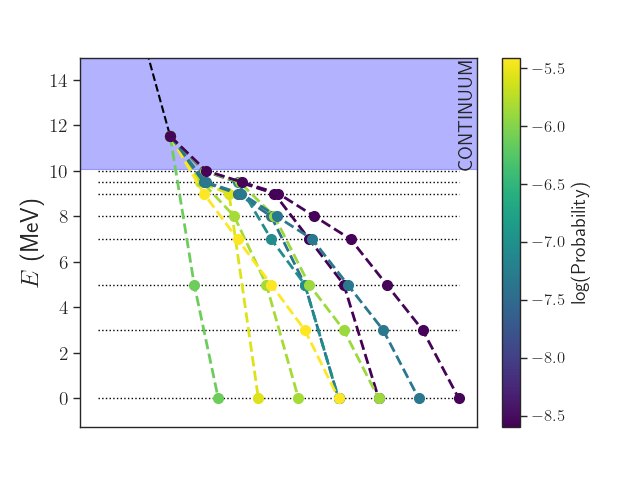

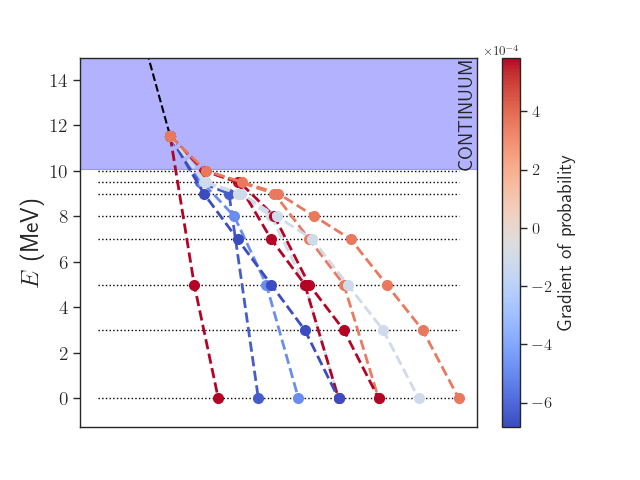

: 

In [187]:
# Plot the discrete tree
%matplotlib widget
discrete_energies = meta_params['discrete_energies']
discrete_path_energies = discrete_energies[discrete_paths]

print(discrete_path_energies.shape)
print(full_discrete_tree_probs[id, :].shape)

# Only plot a subset of the random paths
id = 4
num_paths = 10
idx = np.random.choice(np.arange(len(discrete_paths)), size=num_paths, replace=False)

for mode in ['prob', 'grad']:
    fig, ax = plt.subplots()
    # Plot the continuum energy range (from discrete/continuum boundary to start energy) as a rectangle
    plt.axhspan(discrete_continuum_boundary * 1.01, initial_energy[0] * 1.1, alpha=0.3, color='blue')
    # Add a "CONTINUUM" label to the right, rotated 90 degrees
    ax.text(1.00, (discrete_continuum_boundary + sim_last_continuum_energies[id]*1.3)/2, 'CONTINUUM', rotation=90, verticalalignment='center', horizontalalignment='left', size=14)
    # Plot the discrete energy levels as horizontal lines
    ax.hlines(discrete_energies, 0, 1, color='black', linewidth=1, linestyles='dotted')
    ax.set_xticks([])
    ax.set_ylim(top=sim_last_continuum_energies[id] * 1.3)
    ax.set_ylabel(r'$E$ (MeV)', size=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.text(0.075, initial_energy[0], r'E$_i$', verticalalignment='bottom', horizontalalignment='right', size=14)

    # Plot the continuum part of the energy path
    continuum_path = sim_continuum_energies[id, :sim_last_continuum_energies_idx[id]+1]
    x_axis = np.linspace(0, 0.2, sim_last_continuum_energies_idx[id]+1)
    ax.plot(x_axis[:sim_last_continuum_energies_idx[id]+1], continuum_path, c='black', marker='o', linestyle='--', linewidth=1.5, markersize=7)


    # Colors
    if mode == 'prob':
        cmap = plt.cm.viridis
        max_prob = np.log(np.max(full_discrete_tree_probs[id, idx]))
        min_prob = np.log(np.min(full_discrete_tree_probs[id, idx]))
        norm = plt.Normalize(vmin=min_prob, vmax=max_prob)

    elif mode == 'grad':
        parameter = 'beta'
        cmap = plt.cm.coolwarm
        max_grad = np.max(grad_theta_full_discrete_tree_probs[parameter][id, idx])
        min_grad = np.min(grad_theta_full_discrete_tree_probs[parameter][id, idx])
        norm = plt.Normalize(vmin=min_grad, vmax=max_grad)

        print(max_grad, min_grad)

    # Plot each path in the discrete tree
    for i in range(len(discrete_paths)):
        if i not in idx:
            continue
        # Get the energies in the path
        path_energies = discrete_path_energies[i, :]
        original_length = len(path_energies)
        # Remove all trailing 0s but the first
        path_energies = path_energies[path_energies != 0]
        path_energies = np.append(path_energies, 0)
        # Insert the last continuum energy
        path_energies = np.insert(path_energies, 0, sim_last_continuum_energies[id])
        # Get the probabilities of each path
        path_prob = float(full_discrete_tree_probs[id, i])
        # Get the gradients in the path
        path_grad = grad_theta_full_discrete_tree_probs['alpha'][id, i]

        coloring = np.log(path_prob) if mode == 'prob' else path_grad

        x_axis = np.linspace(0.2, 1 * len(path_energies)/(original_length+1), len(path_energies))
        ax.plot(x_axis, path_energies, marker='o', linestyle='--', linewidth=2.0, markersize=7, alpha=1.0, color=cmap(norm(coloring)))

    # Create a ScalarMappable and associate it with the colormap and normalization
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # This line is important to ensure the colorbar works with ScalarMappable
    # Add a colorbar, specifying the axes to use
    cbar = fig.colorbar(sm, ax=ax)
    label = r'log(Probability)' if mode == 'prob' else r'Gradient of probability'
    cbar.set_label(label, size=14)
    cbar.ax.tick_params(labelsize=12)

    if mode == 'grad':
        # Use scientific notation for the colorbar ticks
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()
        
    #fig.tight_layout()

    # Save each figure as svg
    plt.savefig('saved_images/{}'.format('discrete_tree_{}.svg'.format(mode)), format='svg', dpi=1200)



In [55]:
E_IDX = 1

def sample_and_get_updates(truth_energy_paths, initial_energy, tree_body, cdf_root_fun, kernel, sim_meta_params, sim_params, nominal_sim_params,
                            key, sample_num, discrete_cut_percentage=0.1):
    key, subkey = random.split(key)
    sim_continuum_energies, sim_last_continuum_energies, sim_last_continuum_energies_idx, sim_continuum_cuts, sim_energy_theta_gradients,\
            sim_energy_total_theta_gradients, sim_energy_Ei_gradients, sim_continuum_cut_gradients =\
                sampling.sample_continuum_path(initial_energy, sim_meta_params, sim_params, 
                                            subkey, cdf_root_fun, sample_num=sample_num, passes=1,
                                            max_continuum_steps=4, use_continuum_cut=True,
                                            enforce_decay_to_discrete=True)
    
    discrete_continuum_boundary = sim_meta_params['discrete_continuum_boundary']

    # Get rid of all paths shorter than E_IDX + 1
    truth_energy_paths = [fep for fep in truth_energy_paths if len(fep) >= (E_IDX + 1)]
    continuum_truth_energies = jnp.array([truth_energy_paths[i][E_IDX] for i in range(len(truth_energy_paths)) if truth_energy_paths[i][E_IDX] >= discrete_continuum_boundary])

    # Get the gradients for the continuum energies, i.e., for paths that are still in the continuum at E_IDX
    paths_in_the_continuum_idx = np.where(sim_continuum_energies[:, E_IDX] >= discrete_continuum_boundary)[0]
    paths_in_the_discrete_idx = np.where(sim_continuum_energies[:, E_IDX] < discrete_continuum_boundary)[0]

    sampled_energies = sim_continuum_energies[paths_in_the_continuum_idx, E_IDX]
    sampled_energy_theta_gradients = {}
    sampled_energy_total_theta_gradients = {}
    for param in sim_params:
        sampled_energy_theta_gradients[param] = sim_energy_theta_gradients[param][paths_in_the_continuum_idx, E_IDX]
        sampled_energy_total_theta_gradients[param] = sim_energy_total_theta_gradients[param][paths_in_the_continuum_idx, E_IDX]
    weights = jnp.ones(len(sampled_energies))

    continuum_mmd_loss = mmd_loss_weighted(continuum_truth_energies, sampled_energies, weights, kernel)
    grad_continuum_mmd_loss_val = grad_mmd_loss_weighted(continuum_truth_energies, sampled_energies, weights, kernel)

    #print(mmd_loss, grad_mmd_loss_val)

    # ----------------------------------------------------------------------------------------------------------------------

    # Get the gradients for the discrete energies
    discrete_truth_energies = jnp.array([truth_energy_paths[i][E_IDX] for i in range(len(truth_energy_paths)) if truth_energy_paths[i][E_IDX] < discrete_continuum_boundary])
    
    # Tree body (does not depend on the parameters for now)
    discrete_tree_body_val, discrete_paths = tree_body

    # What are the last continuum energies in the paths that have decayed to discrete at or before E_IDX? 
    discrete_last_continuum_energies = sim_last_continuum_energies[paths_in_the_discrete_idx]
    discrete_last_continuum_energies_idx = sim_last_continuum_energies_idx[paths_in_the_discrete_idx]
    # What are the indices corresponding to the discrete energies that we want to sample
    discrete_paths_idx = E_IDX - discrete_last_continuum_energies_idx - 1

    # Full tree (probabilities of discrete paths)
    full_discrete_tree_probs, discrete_paths = sampling.get_full_discrete_tree_vmap(discrete_last_continuum_energies, (discrete_tree_body_val, discrete_paths), sim_meta_params, sim_params)
    grad_theta_full_discrete_tree_probs, _ = grad_theta_full_discrete_tree_vmap(discrete_last_continuum_energies, (discrete_tree_body_val, discrete_paths), sim_meta_params, sim_params)
    grad_continuum_energy_full_discrete_tree_probs, _ = grad_energy_full_discrete_tree_vmap(discrete_last_continuum_energies, (discrete_tree_body_val, discrete_paths), sim_meta_params, sim_params)
    discrete_path_energies = sim_meta_params['discrete_energies'][discrete_paths]

    # Let's get the *expected value* of the energy and the gradients over the discrete tree for each sampled continuum path that has decayed to discrete at or before E_IDX
    discrete_energies_ev = jnp.einsum('ij,ji->i', full_discrete_tree_probs, discrete_path_energies[:, discrete_paths_idx])
    discrete_energies_continuum_energy_gradients_ev = jnp.einsum('ij,ji->i', grad_continuum_energy_full_discrete_tree_probs, discrete_path_energies[:, discrete_paths_idx])
    discrete_energies_theta_gradients_ev = {}

    # Cut percentage (when we compute the gradients using the full discrete path tree, things explode quickly. We need to select a subset of the events)
    cut_idx = int(discrete_cut_percentage * len(discrete_paths_idx))
    cut_idx = max(cut_idx, 1)
    discrete_cut_percentage = cut_idx / len(discrete_paths_idx) * 1
    #print(cut_idx, cut_percentage, "CUT")
    for param in sim_params:
        #discrete_energies_theta_gradients_ev[param] = jnp.einsum('ij,ji->i', grad_theta_full_discrete_tree_probs[param], discrete_path_energies[:, discrete_paths_idx])
        discrete_energies_theta_gradients_ev[param] = grad_theta_full_discrete_tree_probs[param][:cut_idx, :].flatten()
        #print(grad_theta_full_discrete_tree_probs[param].shape, discrete_paths_idx.shape, "DSLKAJHD")

    # discrete_mmd_loss_ev = mmd_loss_weighted(discrete_truth_energies, discrete_energies_ev, jnp.ones(len(discrete_energies_ev)), kernel)
    # grad_discrete_mmd_loss_val = grad_mmd_loss_weighted(discrete_truth_energies, discrete_energies_ev, jnp.ones(len(discrete_energies_ev)), kernel)

    weights2 = full_discrete_tree_probs[:cut_idx, :].flatten()
    dpe2 = discrete_path_energies[:, discrete_paths_idx[:cut_idx]].T.flatten()
    total_discrete_mmd_loss_ev_2 = mmd_loss_weighted(discrete_truth_energies, dpe2, weights2, kernel)
   #print("TDL2", total_discrete_mmd_loss_ev_2)
    
    discrete_mmd_loss_ev = total_discrete_mmd_loss_ev_2 * discrete_cut_percentage
    grad_discrete_mmd_loss_val = grad_mmd_loss_weighted(discrete_truth_energies, dpe2, weights2, kernel) * discrete_cut_percentage
    #print(discrete_grad_mmd_loss_ev.shape, dpe2.shape)

    print("TDL", discrete_mmd_loss_ev)
    print("TCL", continuum_mmd_loss)
    
    #discrete_grad_mmd_loss_ev = grad_mmd_loss_weighted(truth_energies, discrete_energies_ev, jnp.ones(len(discrete_energies_ev)), gaussian_kernel_vmap)

    grad_of_expected_value_continuum = {}
    grad_of_expected_value_discrete = {}
    for param in sim_params:
        grad_of_expected_value_continuum[param] = jnp.mean(grad_continuum_mmd_loss_val * sampled_energy_total_theta_gradients[param]) / nominal_sim_params[param]
        grad_of_expected_value_discrete[param] = jnp.mean(grad_discrete_mmd_loss_val * discrete_energies_theta_gradients_ev[param]) / nominal_sim_params[param]

        
        #print(param, grad_of_expected_value_continuum[param], grad_of_expected_value_discrete[param])
        # if param == "alpha":
        #     print("DG", discrete_mmd_loss_ev[0:10], grad_discrete_mmd_loss_val[param][0:10])

    #print(paths_in_the_continuum_idx.shape, paths_in_the_discrete_idx.shape)

    updates = {}
    for param in sim_params:
        updates[param] = -0.2 * (grad_of_expected_value_continuum[param] + grad_of_expected_value_discrete[param])
    
    total_mmd_loss = continuum_mmd_loss + discrete_mmd_loss_ev

    return total_mmd_loss, discrete_mmd_loss_ev, continuum_mmd_loss, grad_of_expected_value_continuum, grad_of_expected_value_discrete, updates

In [8]:
%load_ext line_profiler

starting_params = {'disp_parameter': 1.0,
                'alpha': 1.0,
                'beta': 1.0}
sample_num = 2000
initial_energy = 23.0 * np.ones(sample_num) #+ np.random.normal(size=(sample_num,)) * 4
sim_meta_params = META_PARAMS
tree_body = sampling.get_discrete_tree_body(meta_params, params)
key, subkey = random.split(key)

%lprun -f sample_and_get_updates sample_and_get_updates(full_energy_paths, initial_energy, tree_body,\
     jax_cdf_minimum, gaussian_kernel_vmap, sim_meta_params, starting_params, NOMINAL_PARAMS,\
     subkey, sample_num=sample_num, discrete_cut_percentage=0.1)

KeyboardInterrupt: 

In [56]:
def gradient_descent(truth_energy_paths, initial_energy, tree_body, cdf_root_fun, kernel, sim_meta_params, starting_params, true_params, nominal_sim_params,
                            key, sample_num, max_iter_num, discrete_cut_percentage=0.1):
    params_evolution = {param: [starting_params[param]] for param in starting_params}
    loss_evolution = []

    sim_params = copy.deepcopy(starting_params)

    for i in range(max_iter_num):
        used_sample_num = sample_num
        # Progressively increase the number of samples when reaching max_iter_num
        # if i > 0.8 * max_iter_num:
        #     used_sample_num = int(2 * (i - 0.8 * max_iter_num) / (0.2 * max_iter_num) * sample_num)
        # else:
        #     used_sample_num = sample_num
        # initial_energy = 23.0 * np.ones(used_sample_num)

        key, subkey = random.split(key)
        total_mmd_loss, discrete_mmd_loss_ev, continuum_mmd_loss, grad_of_expected_value_continuum, grad_of_expected_value_discrete, updates =\
            sample_and_get_updates(truth_energy_paths, initial_energy, tree_body, cdf_root_fun, kernel, sim_meta_params,\
                                    sim_params, nominal_sim_params, subkey, sample_num=used_sample_num, discrete_cut_percentage=discrete_cut_percentage)
        print('--------------------')
        print(i, "LOSS", total_mmd_loss)

        loss_evolution.append(total_mmd_loss)
        for param in sim_params:
            if param == 'alpha' or param == 'disp_parameter':
                # If the update is larger than 10% of the current value, then we clip it
                if param == 'disp_parameter':
                    updates[param] *= 1.0
                if np.abs(updates[param]) > np.abs(sim_params[param] * 0.2):
                    updates[param] = np.sign(updates[param]) * np.abs(sim_params[param] * 0.2)
                    
                sim_params[param] += updates[param]
            
            params_evolution[param].append(sim_params[param])

            print(param, sim_params[param])
        
        if np.abs(sim_params['alpha'] - true_params['alpha']) < 0.005 and np.abs(sim_params['disp_parameter'] - true_params['disp_parameter']) < 0.005:
            break

    loss_evolution = np.array(loss_evolution)

    return params_evolution, loss_evolution
    

In [49]:
starting_params = {'disp_parameter': 1.6,
                'alpha': 1.11,
                'beta': 1.0}
true_params = {'disp_parameter': 1.5,
                'alpha': 1.0,
                'beta': 1.0}
sample_num = 500
initial_energy = 23.0 * np.ones(sample_num)
sim_meta_params = META_PARAMS
tree_body = sampling.get_discrete_tree_body(meta_params, params)

key, subkey = random.split(key)

params_evolution, loss_evolution = gradient_descent(full_energy_paths, initial_energy, tree_body,\
        jax_cdf_minimum, gaussian_kernel_vmap, sim_meta_params, starting_params, true_params, NOMINAL_PARAMS,\
        subkey, sample_num=sample_num, max_iter_num=200, discrete_cut_percentage=0.05)

Pass 1 of 1
TDL -0.2443172
TCL -5.970766
--------------------
0 LOSS -6.215083
disp_parameter 1.5848476
alpha 1.1071995
beta 1.0
Pass 1 of 1
TDL -0.23762071
TCL -5.993852
--------------------
1 LOSS -6.231473
disp_parameter 1.5826641
alpha 1.1053325
beta 1.0
Pass 1 of 1
TDL -0.23658688
TCL -5.980291
--------------------
2 LOSS -6.216878
disp_parameter 1.586192
alpha 1.1050504
beta 1.0
Pass 1 of 1
TDL -0.2376725
TCL -5.968891
--------------------
3 LOSS -6.2065635
disp_parameter 1.5811206
alpha 1.1034074
beta 1.0
Pass 1 of 1
TDL -0.2295933
TCL -5.9743223
--------------------
4 LOSS -6.2039156
disp_parameter 1.5626864
alpha 1.0994395
beta 1.0
Pass 1 of 1
TDL -0.24682994
TCL -5.97838
--------------------
5 LOSS -6.22521
disp_parameter 1.5618539
alpha 1.0971073
beta 1.0
Pass 1 of 1
TDL -0.23236446
TCL -6.025264
--------------------
6 LOSS -6.2576284
disp_parameter 1.5501013
alpha 1.0924369
beta 1.0
Pass 1 of 1
TDL -0.23647378
TCL -6.0039325
--------------------
7 LOSS -6.240406
disp_parame

In [50]:
# Save the evolution of the parameters
name = 'params_evolution_{}.pkl'.format('2')
with open('pickles/{}'.format(name), 'wb') as f:
    pickle.dump((params_evolution, loss_evolution), f)

In [25]:
next_params = {param: params_evolution[param][-1] for param in params_evolution}
sample_num = 750
initial_energy = 23.0 * np.ones(sample_num)
sim_meta_params = META_PARAMS
tree_body = sampling.get_discrete_tree_body(meta_params, params)

key, subkey = random.split(key)

params_evolution, loss_evolution = gradient_descent(full_energy_paths, initial_energy, tree_body,\
        jax_cdf_minimum, gaussian_kernel_vmap, sim_meta_params, next_params, true_params, NOMINAL_PARAMS,\
        subkey, sample_num=sample_num, max_iter_num=500, discrete_cut_percentage=0.05)

Pass 1 of 1


KeyboardInterrupt: 

/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/1810285347.py:26: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()
/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/1810285347.py:53: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(scatter)
/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/1810285347.py:67: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(loss_evolution_r[i])


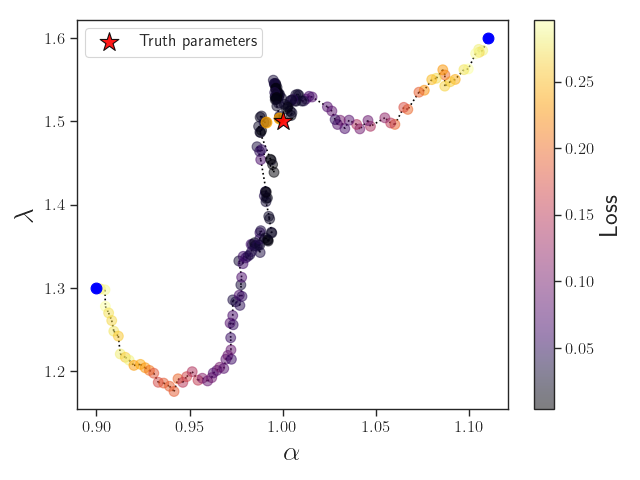

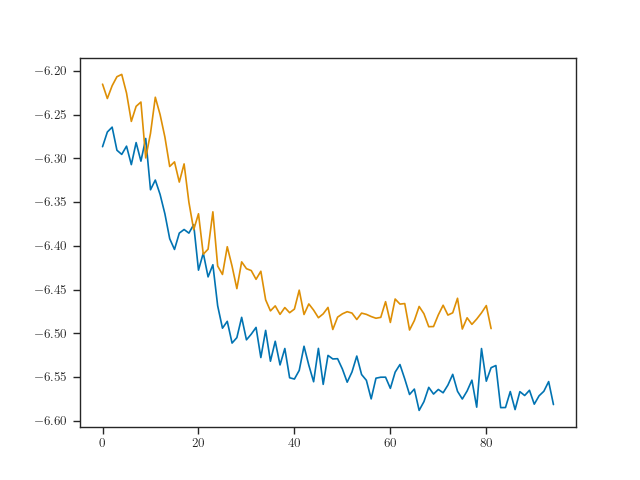

In [181]:
# Plot the evolution of the parameters in 2D
true_params = {'disp_parameter': 1.5,
                'alpha': 1.0,
                'beta': 1.0}

read = True
if read:
    params_evolution_r = []
    loss_evolution_r = []
    for label in ['1', '2']:
        name = 'params_evolution_{}.pkl'.format(label)
        with open('pickles/{}'.format(name), 'rb') as f:
            params_evolution_i, loss_evolution_i = pickle.load(f)
        params_evolution_r.append(params_evolution_i)
        loss_evolution_r.append(loss_evolution_i)
else:
    params_evolution_r = [params_evolution]
    loss_evolution_r = [loss_evolution]



param_1 = 'alpha'
param_2 = 'disp_parameter'

# Make a scatter colored by the loss
fig, ax = plt.subplots()
ax.set_xlabel(PARAMS_LATEX[param_1], size=20)
ax.set_ylabel(PARAMS_LATEX[param_2], size=20)
ax.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()

for i in range(len(params_evolution_r)):

    pe_1 = params_evolution_r[i][param_1]
    pe_2 = params_evolution_r[i][param_2]
    le = loss_evolution_r[i] + 6.5

    scatter = ax.scatter(pe_1[1:], pe_2[1:], c=le, cmap='inferno', s=50, alpha=0.5)

    # Add dashed lines connecting the points
    for i in range(len(pe_1) - 1):
        ax.plot([pe_1[i], pe_1[i+1]], [pe_2[i], pe_2[i+1]], color='black', linestyle=':', zorder=-1)
        # Add arrow head at the end of the line
        #ax.annotate("", xy=(pe_1[i+1], pe_2[i+1]), xytext=(pe_1[i], pe_2[i]), arrowprops=dict(arrowstyle="->", linestyle=':', color='black'))
    # Plot a square at the start
    ax.scatter(pe_1[0], pe_2[0], marker='o', color='blue', s=60, zorder=200)
    ax.scatter(pe_1[-1], pe_2[-1], marker='o', color='orange', s=60, zorder=200, alpha=0.7)

# Plot a star at the true parameter
ax.scatter(true_params[param_1], true_params[param_2], marker='*', color='red', s=200, zorder=400, edgecolors='black', alpha=0.9, label='Truth parameters')

# Add a colorbar
cbar = fig.colorbar(scatter)
cbar.set_label('Loss', size=18)
cbar.ax.tick_params(labelsize=12)

# Add a legend
ax.legend(loc='upper left', fontsize=12)

# Save the figure as svg
plt.savefig('saved_images/{}'.format('params_evolution.svg'), format='svg', dpi=1200)

# --------------
# Plot the loss
plt.figure()
for i in range(len(loss_evolution_r)):
    plt.plot(loss_evolution_r[i])


In [77]:
# Loss plot for a range of the parameters

%matplotlib widget
starting_params = {'disp_parameter': 1.5,
                'alpha': 1.0,
                'beta': 1.0}
sim_params = copy.deepcopy(starting_params)
sim_meta_params = META_PARAMS

sample_num = 500
passes = 7

initial_energy = 23.0 * np.ones(sample_num)
tree_body = sampling.get_discrete_tree_body(meta_params, params)

disp_parameters = jnp.linspace(1.1, 1.9, 30)
alphas = jnp.linspace(0.7, 1.3, 30)
betas = jnp.linspace(0.7, 1.3, 30)

to_plot = alphas

total_mmd_losses = np.zeros((passes, len(to_plot)))
continuum_mmd_losses = np.zeros((passes, len(to_plot)))
discrete_mmd_losses = np.zeros((passes, len(to_plot)))

for j in range(passes):
    for i, val in enumerate(to_plot):
        print('\n')
        print('-------------------')
        print(i, val)
        key, subkey = random.split(key)

        #sim_params['disp_parameter'] = val
        sim_params['alpha'] = val
        #sim_params['beta'] = val

        total_mmd_loss, discrete_mmd_loss_ev, continuum_mmd_loss, grad_of_expected_value_continuum, grad_of_expected_value_discrete, updates =\
                                     sample_and_get_updates(full_energy_paths, initial_energy, tree_body, jax_cdf_minimum, 
                                                            gaussian_kernel_vmap, sim_meta_params, sim_params, NOMINAL_PARAMS, subkey,\
                                                            sample_num=sample_num, discrete_cut_percentage=0.01)
        # key, subkey = random.split(key)
        # total_mmd_loss_2, discrete_mmd_loss_ev_2, continuum_mmd_loss_2, grad_of_expected_value_continuum_2, grad_of_expected_value_discrete_2, updates_2 =\
        #                         sample_and_get_updates(full_energy_paths, initial_energy, tree_body, jax_cdf_minimum, 
        #                                             gaussian_kernel_vmap, sim_meta_params, sim_params, NOMINAL_PARAMS, subkey,\
        #                                             sample_num=sample_num, discrete_cut_percentage=0.01)

        total_mmd_losses[j, i] = total_mmd_loss #+ total_mmd_loss_2
        continuum_mmd_losses[j, i] = continuum_mmd_loss #+ continuum_mmd_loss_2
        discrete_mmd_losses[j, i] = discrete_mmd_loss_ev #+ discrete_mmd_loss_ev_2



-------------------
0 0.7
Pass 1 of 1
TDL -0.031861544
TCL -6.1029377


-------------------
1 0.72068965
Pass 1 of 1
TDL -0.029236605
TCL -6.1042743


-------------------
2 0.7413793
Pass 1 of 1
TDL -0.05491588
TCL -6.0421066


-------------------
3 0.7620689
Pass 1 of 1
TDL -0.05120459
TCL -5.951097


-------------------
4 0.7827586
Pass 1 of 1
TDL -0.047797207
TCL -5.924832


-------------------
5 0.80344826
Pass 1 of 1
TDL -0.047779612
TCL -5.8581324


-------------------
6 0.8241379
Pass 1 of 1
TDL -0.048655994
TCL -5.855744


-------------------
7 0.84482753
Pass 1 of 1
TDL -0.047101162
TCL -5.8625593


-------------------
8 0.8655172
Pass 1 of 1
TDL -0.04979315
TCL -5.900767


-------------------
9 0.88620687
Pass 1 of 1
TDL -0.031589013
TCL -5.8994594


-------------------
10 0.90689653
Pass 1 of 1
TDL -0.03151047
TCL -5.966992


-------------------
11 0.92758614
Pass 1 of 1
TDL -0.03471398
TCL -6.0725656


-------------------
12 0.94827586
Pass 1 of 1
TDL -0.031490177
TCL -6.

/var/folders/jn/g_gtx_qn7f9411g8ktr24lrh0000gn/T/ipykernel_93723/3489609349.py:9: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()


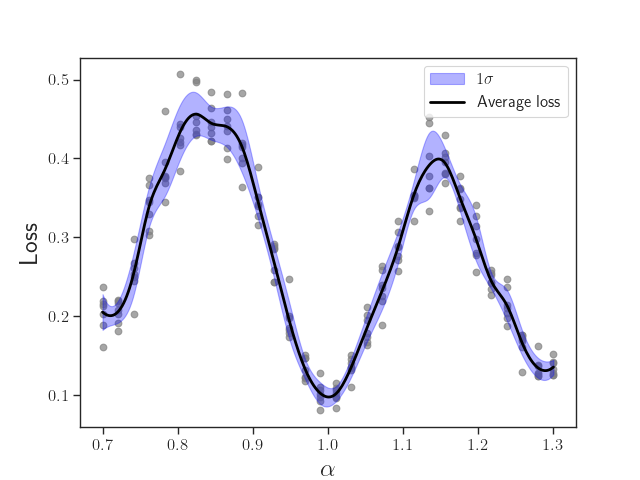

In [182]:
%matplotlib widget

# Get the mean and std of the losses
total_mmd_losses_mean = np.mean(total_mmd_losses, axis=0)
total_mmd_losses_std = np.std(total_mmd_losses, axis=0)

loss_offset = 6.35

fig, ax = plt.subplots()
for j in range(passes):
    ax.scatter(to_plot, total_mmd_losses[j, :] + loss_offset, color='grey', alpha=0.7)

# Plot the mean and std, with a label for the legend. Make 
#ax.plot(to_plot, total_mmd_losses_mean + loss_offset, label='Average loss', color='black', linewidth=2.0)
#ax.fill_between(to_plot, total_mmd_losses_mean - total_mmd_losses_std + loss_offset, total_mmd_losses_mean + total_mmd_losses_std + loss_offset, alpha=0.3, color='blue', label=r'$1 \sigma$')

# Smooth out the 1 sigma region
x = to_plot
y1 = total_mmd_losses_mean - total_mmd_losses_std + loss_offset
y2 = total_mmd_losses_mean + total_mmd_losses_std + loss_offset
x_new = np.linspace(x.min(), x.max(), 300)
y1_smooth = interp1d(x, y1, kind='cubic')(x_new)
y2_smooth = interp1d(x, y2, kind='cubic')(x_new)
ax.fill_between(x_new, y1_smooth, y2_smooth, alpha=0.3, color='blue', label=r'$1 \sigma$')
# Smooth out the mean
y_mean_smooth = interp1d(x, total_mmd_losses_mean + loss_offset, kind='cubic')(x_new)
ax.plot(x_new, y_mean_smooth, color='black', linewidth=2.0, label='Average loss')


# Legend
ax.legend(loc='upper right', fontsize=12)

# Larger ticks
ax.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel(r'$\alpha$', size=18)
plt.ylabel('Loss', size=18)

# Save the figure as svg
plt.savefig('saved_images/{}'.format('loss_vs_alpha.svg'), format='svg', dpi=1200)

# plt.figure()
# for j in range(passes):
#     plt.scatter(to_plot, continuum_mmd_losses[j, :], label='Continuum')
# plt.figure()
# for j in range(passes):
#     plt.scatter(to_plot, discrete_mmd_losses[j, :], label='Discrete')


## Get the expected value of a function and its derivative